.<center> 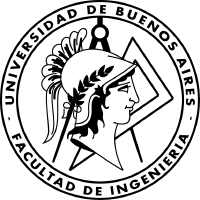



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP5: Árboles de Decisión**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


Una prestigiosa institución de educación superior confeccionó una base de datos con el fin de predecir la deserción o el éxito académico de los estudiantes. El conjunto de datos incluye información conocida en el momento de la inscripción del estudiante (trayectoria académica, datos demogréficos y factores socioeconómicos) y el rendimiento académico de los estudiantes al final del primer y segundo semestre.

## (a) Exploración de datos

In [ ]:
!pip3 install -U ucimlrepo

### (a.1)

Se carga la base de datos y se separa en $X$ e $y$, donde $X$ son las features e $y$ es el target.

In [ ]:
import numpy as np
from ucimlrepo import fetch_ucirepo, list_available_datasets
df = fetch_ucirepo(id=697)

X = df.data.features
y = df.data.targets
print(np.unique(y))

['Dropout' 'Enrolled' 'Graduate']


### (a.2)

Se modifica la variable $y$, descartando la clasificación "Enrolled" para tener solo dos clasificacion: "Dropout" y "Graduate". Para que $y$ sea binaria se le asigna el valor $0$ a "Dropout" y $1$ a "Graduate".

In [ ]:
mask = y['Target'].isin(['Dropout', 'Graduate'])
X = X[mask].copy()
y = y[mask].copy()
y_binary = y['Target'].map({'Dropout': 0, 'Graduate': 1})

### (a.3)

A continuación, se observan todas las features de la base de datos. Cada feature fue catalogada como nominal u ordinal dependiendo de su naturaleza. Las features "Previous qualification", "Mother's qualification" y "Father's qualification" fueron ordenadas para que puedan ser clasificadas como ordinales. Las nominales fueron codificadas como *One-Hot* con la función *get_dummies* de *Pandas*.

* Marital status: nominal
* Application mode: nominal
* Application order: ordinal
* Course: nominal
* Daytime/evening attendance: nominal
* Previous qualification: ordinal
* Previous qualification (grade): ordinal
* Nacionality: nominal
* Mother's qualification: ordinal
* Father's qualification: ordinal
* Mother's occupation: nominal
* Father's occupation: nominal
* Admission grade: ordinal
* Displaced: nominal binario
* Educational special needs: nominal binario
* Debtor: nominal binario
* Tuition fees up to date: nominal binario
* Gender: nominal binario
* Scholarship holder: nominal binario
* Age at enrollment: ordinal
* International: nominal binario
* Curricular units 1st sem (credited): ordinal
* Curricular units 1st sem (enrolled): ordinal
* Curricular units 1st sem (evaluations): ordinal
* Curricular units 1st sem (approved): ordinal
* Curricular units 1st sem (grade): ordinal
* Curricular units 1st sem (without evaluations): ordinal
* Curricular units 2nd sem (credited): ordinal
* Curricular units 2nd sem (enrolled): ordinal
* Curricular units 2nd sem (evaluations): ordinal
* Curricular units 2nd sem (approved): ordinal
* Curricular units 2nd sem (grade): ordinal
* Curricular units 2nd sem (without evaluations): ordinal
* Unemployment rate: ordinal
* Inflation rate: ordinal
* GDP: ordinal


In [ ]:
import pandas as pd

# Nombramos las variales ordinales
ordinals = ['Application order', 'Previous qualification', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification",
            'Admission grade', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
            'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
            'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
            'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Age at enrollment'
]

# Nombramos las variables cardinales
nominals = ['Marital Status', 'Application mode', 'Course', 'Daytime/evening attendance', 'Nacionality', "Mother's occupation", "Father's occupation",
            'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

# Mapeo para Previous qualification
Previous_qualification_map = {
    38: 1,  # Basic education 2nd cycle
    19: 2,  # Basic education 3rd cycle
    15: 3,  # 10th year - not completed
    14: 4,  # 10th year
    10: 5,  # 11th year - not completed
    9:  6,  # 12th year - not completed
    12: 7,  # Other (11th year)
    1:  8,  # Secondary education
    40: 9,  # Higher education degree (1st cycle)
    42: 10, # Professional higher technical
    2:  11, # Higher education - bachelor's
    3:  12, # Higher education - degree
    4:  13, # Higher education - master's
    43: 14, # Higher education - master (2nd cycle)
    5:  15, # Higher education - doctorate
    39: 16, # Technological specialization course
    6:  17  # Frequency of higher education
}

# Mapeo para Mother's qualification y Father´s qualification
Parents_qualification_map = {
    35: 1,  # "Can't read or write"
    36: 2,  # "Can read without having a 4th year of schooling"
    37: 3,  # "Basic education 1st cycle (4th/5th year) or equiv."
    38: 4,  # "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv."
    26: 5,  # "7th year of schooling"
    30: 6,  # "8th year of schooling"
    19: 7,  # "Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv."
    29: 8,  # "9th Year of Schooling - Not Completed"
    14: 9,  # "10th Year of Schooling"
    10: 10, # "11th Year of Schooling - Not Completed"
    12: 11, # "Other - 11th Year of Schooling"
    27: 12, # "2nd cycle of the general high school course"
    11: 13, # "7th Year (Old)"
    9:  14, # "12th Year of Schooling - Not Completed"
    1:  15, # "Secondary Education - 12th Year of Schooling or Eq."
    18: 16, # "General commerce course"
    22: 17, # "Technical-professional course"
    39: 18, # "Technological specialization course"
    42: 19, # "Professional higher technical course"
    6:  20, # "Frequency of Higher Education"
    2:  21, # "Higher Education - Bachelor's Degree"
    3:  22, # "Higher Education - Degree"
    40: 23, # "Higher education - degree (1st cycle)"
    41: 24, # "Specialized higher studies course"
    4:  25, # "Higher Education - Master's"
    43: 26, # "Higher Education - Master (2nd cycle)"
    5:  27, # "Higher Education - Doctorate"
    44: 28, # "Higher Education - Doctorate (3rd cycle)"
    34: np.nan, #"Unknown"
}

X['Previous qualification'] = X['Previous qualification'].map(Previous_qualification_map)
X['Mother\'s qualification'] = X['Mother\'s qualification'].map(Parents_qualification_map)
X['Father\'s qualification'] = X['Father\'s qualification'].map(Parents_qualification_map)

# Codificación One-Hot para las nominales
X_encoded = pd.get_dummies(X, columns=nominals, drop_first=True)
print("Shape después del One-Hot:", X_encoded.shape)

Shape después del One-Hot: (3630, 155)


### (a.4)

Se separan los conjuntos de entrenamiento y testeo con la función *train_test_split* y con una proporción de 75% entrenamiento y 25% testeo.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_binary, test_size=0.25)


## (b) Árbol de decisión

### (b.1)

Se entrena al árbol de clasificación maximal con la entropía como función de impureza. La función de impureza de la entropía se define como:

$$H(Q_m)=\sum_kp_{m,k}(1-p_{m,k})$$

donde $p_{m,k}$ es la proporción de muestras de la clase $k$ en el nodo $m$ y $Q_m$ es el conjunto de datos $(x, y)$ en el nodo $m$.



Como puede verse en el gráfico de abajo, la condición de la raíz es que $\text{Curricular units 2nd sem (approved)} \leq 3.5$. A su vez, se pueden ver los primeros nodos que son $\text{Curricular units 1st sem (enrolled) y Tuition fees up to date_1}$

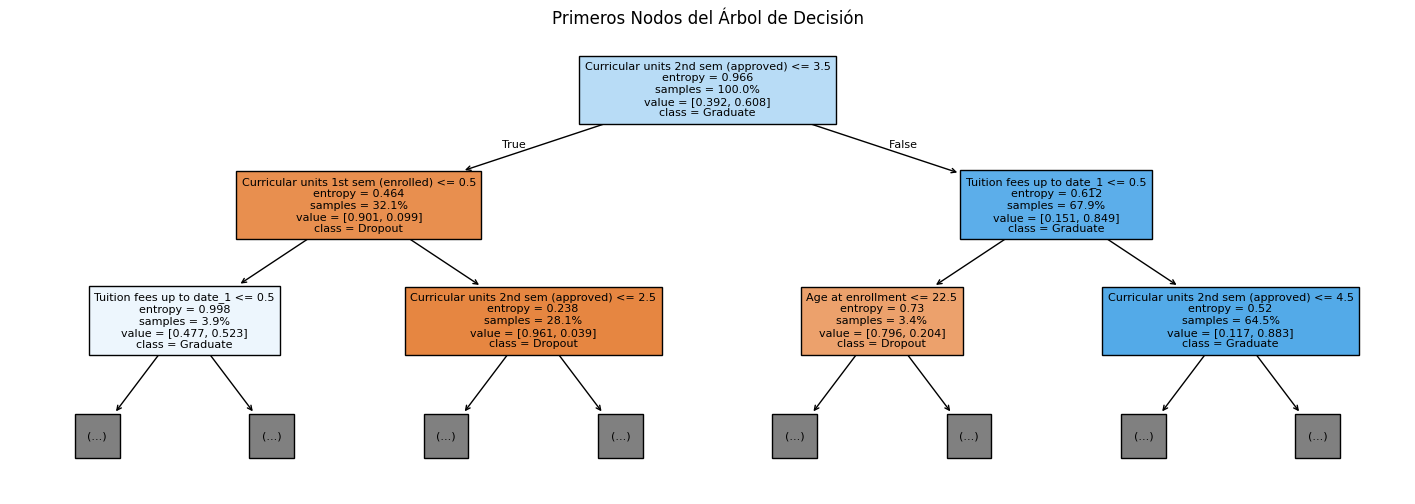

In [ ]:
from sklearn import tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


clf = tree.DecisionTreeClassifier(criterion='entropy')
clf.fit(X_train, y_train)

tree = clf.tree_
features = clf.feature_names_in_

# Graficamos los primeros nodos
plt.figure(figsize=(18,6))
plot_tree(clf, feature_names=clf.feature_names_in_, class_names=['Dropout', 'Graduate'],
    filled=True, max_depth=2,fontsize=8, proportion=True,
)
plt.title("Primeros Nodos del Árbol de Decisión")
plt.show()

### (b.2)

Se grafica el árbol con la función *plot_tree*. El árbol tiene 435 nodos y 218 hojas.

Cantidad total de nodos: 423
Cantidad de hojas: 212


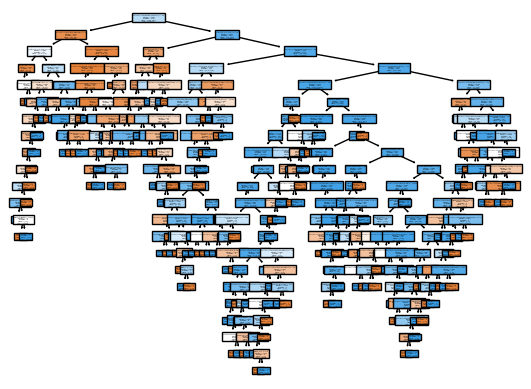

In [ ]:
from sklearn import tree

tree.plot_tree(clf, feature_names=X_train.columns, class_names=['Dropout', 'Graduate'], filled=True)
n_nodes = clf.tree_.node_count
n_leaves = clf.get_n_leaves()

print(f"Cantidad total de nodos: {n_nodes}")
print(f"Cantidad de hojas: {n_leaves}")


### (b.3)


El árbol de decisión maximal con entropía logró un buen desempeño predictivo, capturando patrones relevantes en el rendimiento académico inicial y variables demográficas.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.8568
F1-score: 0.8825


### (b.4)

Según la *Feature Importance* las 2 features más importantes son "Curricular units 2nd sem (approved)" y "Tuition fees up to date_1". Esto coincide con lo que vimos en el árbol de los nodos más importantes.

In [ ]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]  # orden descendente
num_features = 2

print(f"Top {num_features} features más importantes:")
for i in range(num_features):
    print(f"{i+1}. {X_train.columns[indices[i]]}")

Top 2 features más importantes:
1. Curricular units 2nd sem (approved)
2. Tuition fees up to date_1


## (c) Podado

El Podado es una regularización en donde se busca quedarse con el subárbol de menor costo-complejidad. La medida costo-complejidad se calcula como:

$$H_{\alpha}(T)=\sum_{m\in L(T)}\frac{|Q_m|}{n}\cdot H(Q_m)+\alpha\cdot|L(T)|$$

donde $L(T)$ es el conjunto de hojas y $\alpha$ es el parámetro de complejidad.

### (c.1)


Se utilizó la función *cost_complexity_pruning_path* para calcular los valores de $\alpha$ relevantes asociados a la poda del árbol de decisión. Cada valor de $\alpha$ representa un nivel distinto de complejidad del modelo, penalizando los árboles más grandes para evitar sobreajuste.

El árbol maximal ($\alpha=0$) posee la menor impureza pero también la mayor complejidad. A medida que $\alpha$ aumenta, la impureza total crece lentamente mientras que el número de nodos disminuye.

In [ ]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print("Cantidad de valores de α:", len(ccp_alphas))
print("Primeros 10 valores de α:", ccp_alphas[:10])

Cantidad de valores de α: 131
Primeros 10 valores de α: [0.         0.00059451 0.00071641 0.00073475 0.00073475 0.00073475
 0.00078681 0.00097967 0.00101208 0.00101208]


### (c.2)

A continuación, se entrenaron árboles de decisión para cada valor de $\alpha$ obtenido y se calcularon las métricas accuracy y F1-score utilizando el conjunto de testeo.

Del análisis de los resultados se observó el valor de $\alpha$ en el cual ambas métricas alcanzan su valor máimo. Por lo tanto, este valor se seleccionó como el parámetro óptimo para la poda, logrando un modelo más simple sin comprometer significativamente el rendimiento.

El hecho de que el mejor rendimiento se obtenga para un valor de $\alpha > 0$ evidencia que el árbol sin podar presentaba cierto grado de sobreajuste. La poda permitió reducir la complejidad del modelo, mejorando su capacidad de generalización y evitando que se adapte excesivamente a los datos de entrenamiento.

Cantidad total de nodos: 103
Cantidad de hojas: 52
Accuracy: 0.8910
F1-score: 0.9125


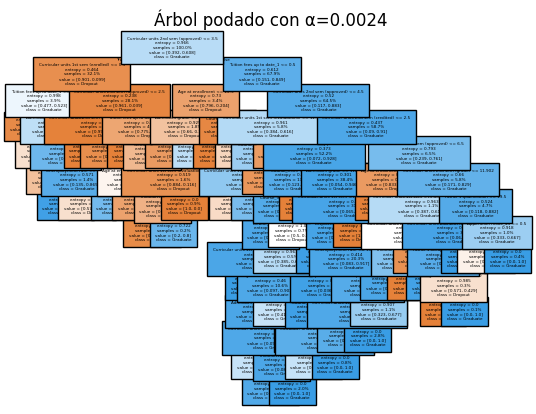

In [ ]:
clfs = []

# entreno un árbol para cada valor de alpha
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeClassifier(random_state=0, criterion='entropy', ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# elige el subíndice del alpha que quiero
idx_alpha = 100

# calculo numero de nodos y hojas
n_nodes = clfs[idx_alpha].tree_.node_count
n_leaves = clfs[idx_alpha].get_n_leaves()
print(f"Cantidad total de nodos: {n_nodes}")
print(f"Cantidad de hojas: {n_leaves}")

# calculo accuracy y F1
y_pred = clfs[idx_alpha].predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")

#gráfico de árbol
tree.plot_tree(clfs[idx_alpha], feature_names=X_train.columns, class_names=['Dropout', 'Graduate'], filled=True, fontsize=3, proportion=True)
plt.title(f"Árbol podado con α={ccp_alphas[idx_alpha]:.4f}")
plt.show()

### (c.3)

Se graficó la cantidad de hojas en función de $\alpha$ y, como se puede observar, esta disminuye notablemente al aumentar el valor de $\alpha$. Esto se debe a que valores más altos de $\alpha$ penalizan la complejidad del árbol durante el proceso de poda, eliminando ramas que aportan poca ganancia de información. En consecuencia, el modelo se simplifica progresivamente, reduciendo el riesgo de sobreajuste y mejorando su capacidad de generalización frente a datos no vistos.

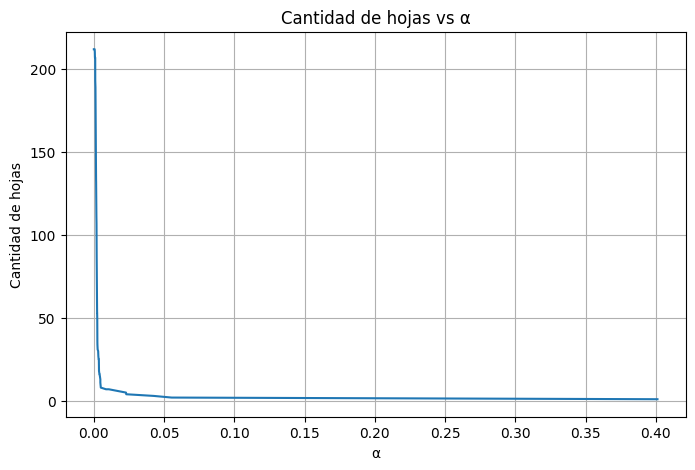

In [ ]:
import matplotlib.pyplot as plt
node_counts = [clf.tree_.node_count for clf in clfs]
leaf_counts = [clf.get_n_leaves() for clf in clfs]

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, leaf_counts)
plt.xlabel("α")
plt.ylabel("Cantidad de hojas")
plt.title("Cantidad de hojas vs α")
plt.grid()
plt.show()

### (c.4)

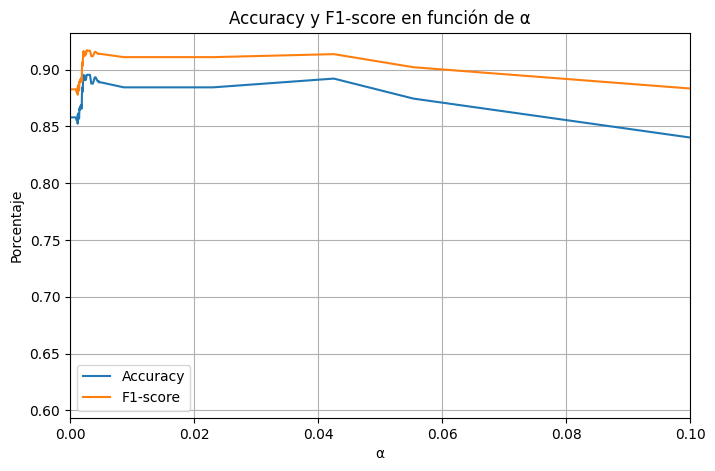

In [ ]:
# gráfico de accuracy y f1-score vs alpha
acc = []
f1 = []

for clf in clfs:
    y_test_pred = clf.predict(X_test)
    acc.append(accuracy_score(y_test, y_test_pred))
    f1.append(f1_score(y_test, y_test_pred))

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, acc, label='Accuracy')
plt.plot(ccp_alphas, f1, label='F1-score')
plt.xlim(0, 0.1)
plt.xlabel("α")
plt.ylabel("Porcentaje")
plt.title("Accuracy y F1-score en función de α")
plt.grid()
plt.legend()
plt.show()

### (c.6)

Se obtienen el mejor $\alpha$ y los valores de accuracy y F1-score para dicho valor. Estos resultados coinciden con los ya mencionados previamente.

In [ ]:
best_idx = f1.index(max(f1))
best_alpha = ccp_alphas[best_idx]
best_clf = clfs[best_idx]

print(f"Mejor α según F1: {best_alpha:.5f}")
print(f"F1 de testeo: {f1[best_idx]:.3f}")
print(f"Accuracy de testeo: {acc[best_idx]:.3f}")

importances = best_clf.feature_importances_
indices = np.argsort(importances)[::-1]  # orden descendente
num_features = 2

print(f"\nTop {num_features} features más importantes:")
for i in range(num_features):
    print(f"{i+1}. {X_train.columns[indices[i]]}")

Mejor α según F1: 0.00269
F1 de testeo: 0.917
Accuracy de testeo: 0.895

Top 2 features más importantes:
1. Curricular units 2nd sem (approved)
2. Tuition fees up to date_1


## (d) Bosque Aleatorio



En bosques aleatorios se entrenan varios algoritmos y para que estos sean variados se buscan dos cosas:
* Para cada nodo se eligen al azar $\sqrt{d_x}$ features, siendo $d_x$ la cantidad total de features.
* Generar conjuntos de datos diferentes del mismo tamaño que el dataset original. Para esto se utiliza una técnica llamada Bootstrap

### (d.1)

Se entrena un bosque aleatorio de 20 árboles utilizando la función RandomForestClassifier de sklearn. Este método combina múltiples árboles de decisión entrenados sobre diferentes subconjuntos de los datos y de las variables, reduciendo la varianza del modelo individual y mejorando la capacidad de generalización.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=0)
rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=20, random_state=0)

### (d.2)


Al evaluar el desempeño del clasificador sobre el conjunto de test, se obtuvieron valores de accuracy y F1-score superiores a los del árbol de decisión individual, lo cual indica que el ensamble logra mitigar el sobreentrenamiento y mejorar la robustez del sistema.

In [ ]:
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy (test): {acc_rf:.3f}")
print(f"F1-score (test): {f1_rf:.3f}")

Accuracy (test): 0.906
F1-score (test): 0.925


### (d.3)

Se calcularon las dos features más importantes del bosque aleatorio y se observó que difieren de las identificadas en el árbol de decisión individual. Esto se debe a que el bosque aleatorio promedia la importancia de cada variable a lo largo de los 20 árboles que lo componen, entrenados sobre diferentes subconjuntos de datos y de características. Como resultado, algunas variables que eran dominantes en el árbol unitario pueden tener menor influencia en el modelo ensamblado, y otras pueden ganar relevancia, reflejando la capacidad del bosque aleatorio para capturar relaciones más generales y reducir el sesgo del modelo.

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # orden descendente
num_features = 2

print(f"Top {num_features} features más importantes:")
for i in range(num_features):
    print(f"{i+1}. {X_train.columns[indices[i]]}")

Top 2 features más importantes:
1. Curricular units 2nd sem (approved)
2. Curricular units 1st sem (approved)
